# Model Comparison & Error Analysis

Compares every trained model on the **scaffold split** test set (primary
evaluation split per project methodology): classical ML (XGBoost, LightGBM,
Random Forest with conformal intervals), a from scratch MPNN (MC dropout
uncertainty), and the chemprop family (default D-MPNN, HPO tuned D-MPNN,
CheMeleon foundation model finetune — all regression MVE uncertainty).

Then digs into *where* the best model fails: applicability domain, the
worst/best individual predictions, and an interactive UMAP of the full
dataset with those failures highlighted in chemical space context.

Note: an earlier pass looked at error *per Murcko scaffold*, but the scaffold
split assigns whole scaffold groups to one bucket only — every scaffold in
the test set turned out to be a singleton (1051 molecules, 1051 unique
scaffolds), so "error per scaffold" was really just "error per molecule" in
disguise. That analysis is dropped in favor of the molecule level ranking
and UMAP view below.

In [1]:
import base64
import sys
from io import BytesIO
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import yaml
from IPython.display import HTML
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator
from scipy.stats import spearmanr
from umap import UMAP

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))  # src/ isn't an installed package

from src.components.feature_engineering import featurize
from src.components.gnn_model import graphs_from_df
from src.components.model_evaluator import applicability_domain, regression_metrics
from src.components.model_trainer import predict_gnn_with_uncertainty, predict_with_interval

config = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
SEED = config["seed"]
SPLITS_DIR = ROOT / config["data"]["splits_dir"]
MODELS_DIR = ROOT / config["models_dir"]
AD_THRESHOLD = config["applicability_domain"]["tanimoto_threshold"]

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

## 1. Load scaffold split

Scaffold split is the headline evaluation since it better reflects real
prospective use than a random split — grouping structurally related
molecules together means the test set represents genuinely novel chemotypes
rather than near duplicates of the training data, so every comparison below
uses `scaffold_test.csv`. Train is only needed for applicability domain
Tanimoto similarity and to refeaturize inputs for the classical and from
scratch models (their saved artifacts are the fitted estimator or weights,
not cached predictions).

In [2]:
train_df = pd.read_csv(SPLITS_DIR / "scaffold_train.csv")
val_df = pd.read_csv(SPLITS_DIR / "scaffold_val.csv")
test_df = pd.read_csv(SPLITS_DIR / "scaffold_test.csv")
train_df.shape, val_df.shape, test_df.shape

((8401, 5), (1050, 5), (1051, 5))

## 2. Generate predictions from every model on the test set

### 2a. Classical ML (conformal prediction intervals via MAPIE)

MAPIE wraps a fitted regressor to produce conformal prediction intervals —
calibrated so the interval is expected to cover the true value at a chosen
confidence level — using held out residuals rather than a parametric
assumption about error distribution. This is the uncertainty estimate for
the tree based models (XGBoost, LightGBM, Random Forest), which don't have a
built in notion of predictive uncertainty on their own.

In [3]:
DESCRIPTOR_KIND = "ecfp"
N_BITS = config["features"]["ecfp_n_bits"]

# Only the fitted estimators were saved, not the featurized test set.
X_test = featurize(test_df, kind=DESCRIPTOR_KIND, n_bits=N_BITS)
y_true = test_df["pIC50"].values

classical_preds = {}
for model_type in ["xgboost", "lightgbm", "random_forest"]:
    model = joblib.load(MODELS_DIR / f"{model_type}_scaffold.joblib")
    y_pred, y_lo, y_hi = predict_with_interval(model, X_test)
    classical_preds[model_type] = {
        "y_pred": np.asarray(y_pred).ravel(),
        "y_unc": (np.asarray(y_hi).ravel() - np.asarray(y_lo).ravel()) / 2,  # conformal half-width
    }

list(classical_preds)

/opt/miniconda3/envs/egfr-env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/egfr-env/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


['xgboost', 'lightgbm', 'random_forest']

### 2b. From scratch MPNN (MC dropout uncertainty)

Unlike the classical models, this GNN's uncertainty comes from Monte Carlo
dropout: running many forward passes with dropout left active at inference
time and treating the spread across those passes as an approximate
predictive uncertainty, rather than a conformal interval or a learned
variance head.

In [4]:
mpnn = joblib.load(MODELS_DIR / "mpnn_scaffold.joblib")
test_graphs = graphs_from_df(test_df)

mpnn_pred, mpnn_std, mpnn_true = predict_gnn_with_uncertainty(
    mpnn, test_graphs, n_mc=config["gnn"]["mc_dropout_samples"], device="cpu"
)

# graphs_from_df silently drops unparsable rows, so align by smiles rather
# than assuming row order matches test_df.
mpnn_smiles = [test_df["smiles"].iloc[i] for i in range(len(test_graphs))]
assert np.allclose(mpnn_true, test_df.set_index("smiles").loc[mpnn_smiles, "pIC50"].values)
mpnn_df = test_df.set_index("smiles").loc[mpnn_smiles].reset_index()
mpnn_df["y_pred"] = mpnn_pred
mpnn_df["y_unc"] = mpnn_std
len(mpnn_df)

1051

### 2c. Chemprop family (D-MPNN default, HPO tuned D-MPNN, CheMeleon finetune)

Each `test_predictions.csv` was written by chemprop with the **prediction**
in the `pIC50` column (and raw `IC50` left untouched from the input) — the
ground truth is rejoined from `scaffold_test.csv` on `molecule_chembl_id`.

In [5]:
CHEMPROP_FAMILY = {
    "chemprop_default": "chemprop",
    "chemprop_dmpnn_hpo": "dmpnn",
    "chemeleon_finetune": "chemeleon",
}

chemprop_preds = {}
truth = test_df.set_index("molecule_chembl_id")["pIC50"]

for model_name, folder in CHEMPROP_FAMILY.items():
    df = pd.read_csv(MODELS_DIR / folder / "scaffold" / "test_predictions.csv")
    df = df.rename(columns={"pIC50": "y_pred", "pIC50_unc": "y_unc"})
    # Re-derive from scaffold_test.csv so every model is scored against the same y_true.
    df["y_true"] = truth.loc[df["molecule_chembl_id"]].values
    chemprop_preds[model_name] = df

chemprop_preds["chemprop_default"].head(3)

,Unnamed: 0,molecule_chembl_id,smiles,IC50,y_pred,y_unc,y_true
0,10273,CHEMBL6030352,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,290.00,5.802085,0.959165,6.54
1,6470,CHEMBL6175072,CCc1cc(Nc2ncc(Cl)c(Nc3ccc(C)c(C)c3P(C)(C)=O)n2...,0.55,9.820425,0.959165,9.26
2,7067,CHEMBL5207462,CN1CCN(c2ccc(-c3ccc4c(=O)n(C(C(=O)Nc5nccs5)c5c...,17.80,8.649450,0.959165,7.75


## 3. Assemble one long format results table

Every model's per molecule prediction, uncertainty, and error side by side.
Note uncertainty columns are **not on a common scale** (conformal interval
half width vs. MC dropout std vs. MVE std) — used only descriptively below,
never compared model to model as an absolute number.

In [6]:
frames = []

for model_type, d in classical_preds.items():
    frames.append(pd.DataFrame({
        "model": model_type,
        "molecule_chembl_id": test_df["molecule_chembl_id"].values,
        "smiles": test_df["smiles"].values,
        "y_true": y_true,
        "y_pred": d["y_pred"],
        "y_unc": d["y_unc"],
    }))

frames.append(pd.DataFrame({
    "model": "mpnn_scratch",
    "molecule_chembl_id": mpnn_df["molecule_chembl_id"].values,
    "smiles": mpnn_df["smiles"].values,
    "y_true": mpnn_df["pIC50"].values,
    "y_pred": mpnn_df["y_pred"].values,
    "y_unc": mpnn_df["y_unc"].values,
}))

for model_name, df in chemprop_preds.items():
    frames.append(pd.DataFrame({
        "model": model_name,
        "molecule_chembl_id": df["molecule_chembl_id"].values,
        "smiles": df["smiles"].values,
        "y_true": df["y_true"].values,
        "y_pred": df["y_pred"].values,
        "y_unc": df["y_unc"].values,
    }))

results = pd.concat(frames, ignore_index=True)
results["error"] = results["y_pred"] - results["y_true"]
results["abs_error"] = results["error"].abs()
results.groupby("model").size()

model
chemeleon_finetune    1051
chemprop_default      1051
chemprop_dmpnn_hpo    1051
lightgbm              1051
mpnn_scratch          1051
random_forest         1051
xgboost               1051
dtype: int64

## 4. Model comparison — RMSE, MAE, R², Spearman ρ

Always reported together per project convention (never R² alone). R² can
look strong from a single skewed direction of error while RMSE/MAE reveal
the actual magnitude of mistakes, and Spearman ρ separately checks whether
compound ranking (which matters most for prioritizing candidates) holds up
even where absolute values are off.

In [7]:
metrics_table = (
    results.groupby("model")
    .apply(lambda g: pd.Series(regression_metrics(g["y_true"].values, g["y_pred"].values)))
    .sort_values("rmse")
)
metrics_table

,rmse,mae,r2,spearman
model,,,,
random_forest,0.889454,0.665822,0.516317,0.732900
chemeleon_finetune,0.933912,0.722148,0.466757,0.681743
lightgbm,0.934020,0.710831,0.466634,0.699646
xgboost,0.947434,0.714775,0.451204,0.690528
chemprop_default,0.972359,0.731977,0.421948,0.676000
chemprop_dmpnn_hpo,0.989050,0.744030,0.401933,0.643408
mpnn_scratch,1.154235,0.925811,0.185480,0.424927


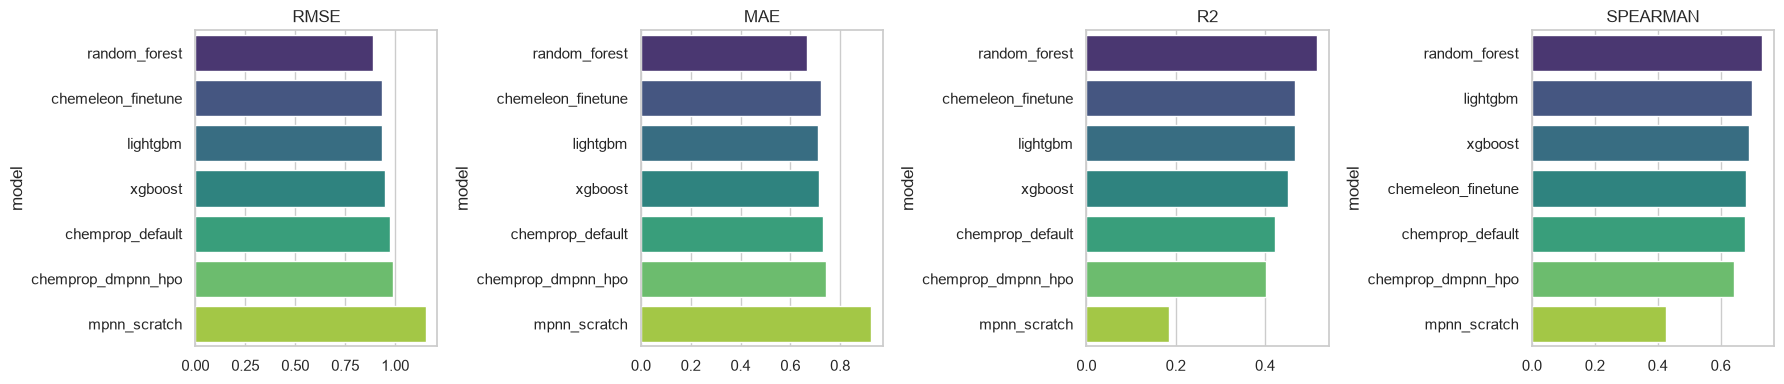

In [8]:
# rmse/mae: lower is better; r2/spearman: higher is better — sort each panel so best is on top.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["rmse", "mae", "r2", "spearman"]):
    order = metrics_table.index if metric in ("rmse", "mae") else metrics_table[metric].sort_values(ascending=False).index
    sns.barplot(x=metrics_table.loc[order, metric], y=order, hue=order, palette="viridis", legend=False, ax=ax)
    ax.set_title(metric.upper())
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 5. Predicted vs. actual, per model

A tight scatter clustered around the diagonal line indicates accurate
predictions; systematic curvature or offset from the diagonal indicates a
bias (e.g. compressing predictions toward the mean rather than genuinely
resolving high/low potency compounds).

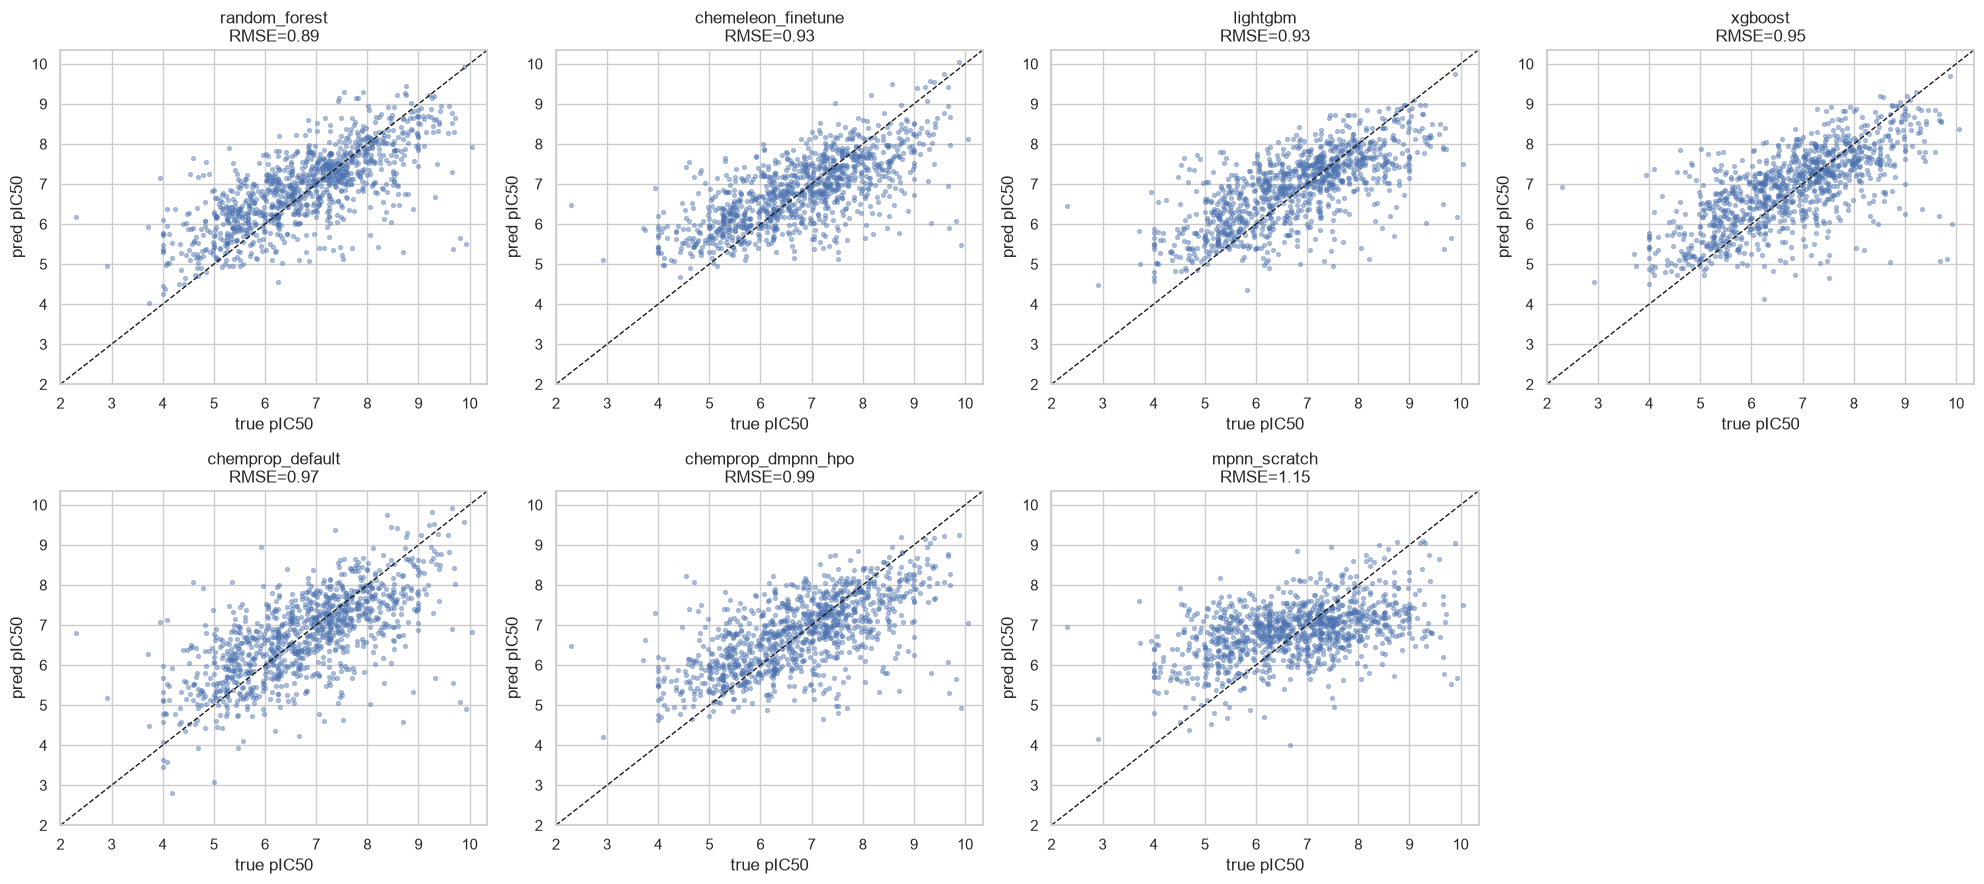

In [9]:
models_order = metrics_table.index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, model in zip(axes.flat, models_order):
    g = results[results["model"] == model]
    ax.scatter(g["y_true"], g["y_pred"], s=8, alpha=0.4)
    lims = [results["y_true"].min() - 0.3, results["y_true"].max() + 0.3]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{model}\nRMSE={metrics_table.loc[model, 'rmse']:.2f}")
    ax.set_xlabel("true pIC50"); ax.set_ylabel("pred pIC50")
for ax in axes.flat[len(models_order):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Error distributions across models

Boxplots reveal spread and outliers that a single RMSE/MAE number hides — a
model can have a similar mean error to another but a much longer tail of
badly wrong predictions.

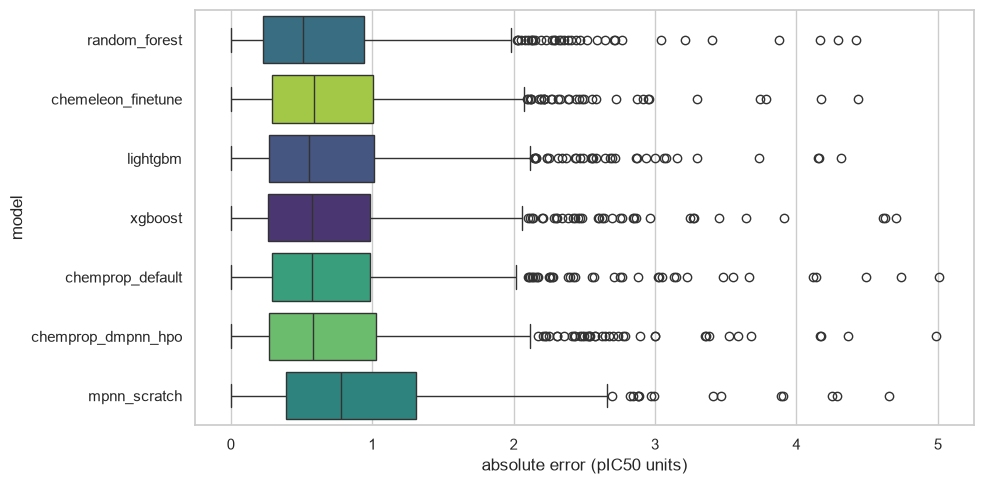

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=results, x="abs_error", y="model", order=models_order, hue="model", palette="viridis", legend=False, ax=ax)
ax.set_xlabel("absolute error (pIC50 units)")
plt.tight_layout()
plt.show()

## 7. Applicability domain — does out of domain correlate with error?

Tanimoto similarity of each test molecule to its nearest training set
neighbor. Below threshold predictions carry a warning, not a
rejection — but they should still show up as harder to predict.

In [11]:
sim, in_domain = applicability_domain(
    test_df["smiles"].tolist(), train_df["smiles"].tolist(), threshold=AD_THRESHOLD
)
ad_lookup = pd.DataFrame({
    "molecule_chembl_id": test_df["molecule_chembl_id"].values,
    "nn_similarity": sim,
    "in_domain": in_domain,
})
results = results.merge(ad_lookup, on="molecule_chembl_id", how="left")

print(f"AD threshold: {AD_THRESHOLD}  |  in-domain: {in_domain.mean():.1%} of test set")
# gap = out-of-domain mean abs error minus in-domain mean abs error
(
    results.groupby(["model", "in_domain"])["abs_error"]
    .mean()
    .unstack()
    .assign(gap=lambda d: d[False] - d[True])
    .loc[models_order]
)

AD threshold: 0.4  |  in-domain: 90.0% of test set


in_domain,False,True,gap
model,,,
random_forest,1.027721,0.625654,0.402067
chemeleon_finetune,1.048785,0.685893,0.362891
lightgbm,1.046245,0.673602,0.372643
xgboost,1.083005,0.673904,0.409101
chemprop_default,1.149661,0.685616,0.464044
chemprop_dmpnn_hpo,1.063938,0.708522,0.355416
mpnn_scratch,1.109290,0.905446,0.203843


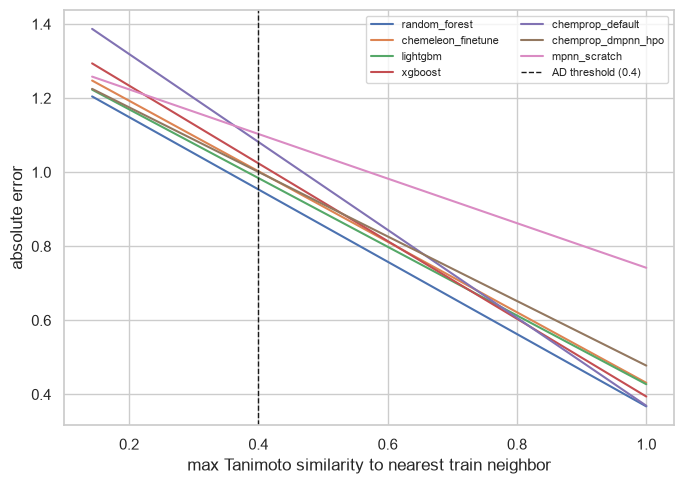

In [12]:
# Trend line, not raw scatter, to avoid overplotting 7 models x 1051 points.
fig, ax = plt.subplots(figsize=(7, 5))
for model in models_order:
    g = results[results["model"] == model]
    sns.regplot(
        x=g["nn_similarity"], y=g["abs_error"], ax=ax, scatter=False,
        label=model, ci=None, line_kws={"linewidth": 1.5},
    )
ax.axvline(AD_THRESHOLD, color="k", ls="--", lw=1, label=f"AD threshold ({AD_THRESHOLD})")
ax.set_xlabel("max Tanimoto similarity to nearest train neighbor")
ax.set_ylabel("absolute error")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 8. Worst & best performing molecules

Ranked by absolute error from the **best model** (lowest scaffold test RMSE,
section 4).

Best model: random_forest

Best 10 (lowest absolute error):


molecule_chembl_id,structure,smiles,y_true,y_pred,abs_error
CHEMBL5972607,,CC(C)N1C=C([C@@H](Nc2cc(Cl)c3ncc(C#N)c(Nc4ccc(F)c(Cl)c4)c3c2)c2cccc3c2CCN(C2COC2)C3)NN1,8.100,8.098000,0.002000
CHEMBL1272325,,O=C(/C=C/CN1CCOCC1)N1CCc2c(sc3ncnc(N[C@H](CO)c4ccccc4)c23)C1,6.765,6.767593,0.002593
CHEMBL5174109,,CN(C)CCN(C)c1ccc(Nc2ncc3cc(CNc4ccccc4)n(C4CCCC4)c3n2)cc1,6.520,6.517233,0.002767
CHEMBL5199169,,COc1cc(N(C)CCN(C)C)c(NC(=O)c2ncccn2)cc1Nc1nccc(-c2cn(C)c3ccccc23)n1,6.840,6.836650,0.003350
CHEMBL421686,,Cc1[nH]c2ncnc(NCc3ccccc3)c2c1C,5.970,5.965900,0.004100
CHEMBL5928819,,COc1cc(N2CCC3(CC2)CN(C)C3)c(C)cc1Nc1ncc(Cl)c(Nc2ccc3sccc3c2P(C)(C)=O)n1,9.210,9.214900,0.004900
CHEMBL3964380,,CCC(=O)Nc1cc2c(Nc3ccc4c(ccn4Cc4ccco4)c3)ncnc2cc1OC,7.070,7.065100,0.004900
CHEMBL3678959,,CC(C)n1c(NC2CCCCC2)nc2cnc(Nc3ccc(N4CCN(C)CC4)cc3)nc21,7.820,7.814680,0.005320
CHEMBL5780557,,CC(C)(C)N1CCC(N2C=C([C@@H](Nc3cc(Cl)c4ncc(C#N)c(Nc5ccc(F)c(Cl)c5)c4c3)c3ccc4sccc4c3)NN2)CC1,7.690,7.695500,0.005500
CHEMBL399438,,N#Cc1cnc2cc(-c3ccc(CN4CCOCC4)cc3)ccc2c1N[C@@H]1C[C@H]1c1ccccc1,6.630,6.623150,0.006850

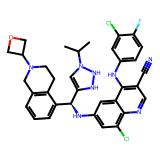
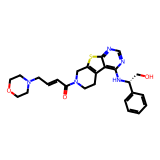
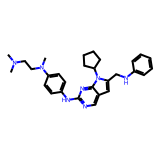
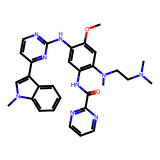
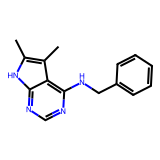
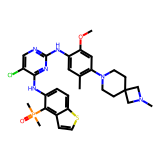
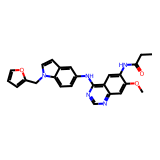
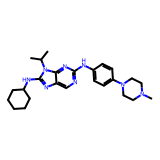
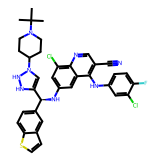
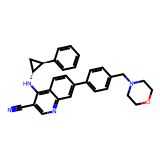


Worst 10 (highest absolute error):


molecule_chembl_id,structure,smiles,y_true,y_pred,abs_error
CHEMBL6170958,,CCOc1ccc(/C=C2/C(=O)N(c3ccc(Cl)cc3)N=C2C)cc1,9.920,5.500501,4.419499
CHEMBL6152892,,CCOc1ccc(C2C(C#N)=C(N)OC3C2C(C)=NN3c2ccc(Cl)cc2)cc1,9.680,5.389664,4.290336
CHEMBL5192793,,COc1ccc(-c2cc(=O)cc(-c3ccc(OC)cc3)o2)cc1,9.820,5.652400,4.167600
CHEMBL261238,,CN(c1cccnc1)c1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cn1,2.300,6.174850,3.874850
CHEMBL6132839,,O=C(CSc1nnc(Nc2ccccc2)s1)N1N=C(c2ccccc2)CC1c1ccc([N+](=O)[O-])cc1,8.700,5.294900,3.405100
CHEMBL5886380,,C=CC(=O)Nc1cccc(Nc2nc(Nc3cccc4c3CCN(C(C)=O)C4)ncc2C(F)(F)F)c1,3.945,7.157850,3.212850
CHEMBL4858176,,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC[Se]CC1,4.600,7.644150,3.044150
CHEMBL590878,,Oc1cc(O)c2cc(O)c(-c3cc(O)c(O)c(O)c3)[o+]c2c1.[Cl-],8.200,5.435950,2.764050
CHEMBL5901984,,C=CC(=O)N1CC(Oc2cc3c(Nc4cccc5cnn(C)c45)ncnc3cc2OC)C1,4.845,7.561300,2.716300
CHEMBL5863176,,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc5cnn(C)c45)ncnc3cn2)CC1,4.540,7.253050,2.713050

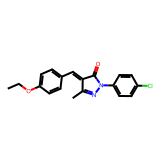
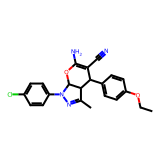
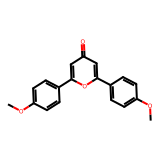
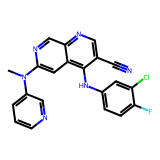
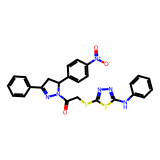
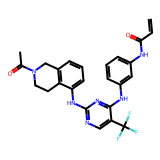
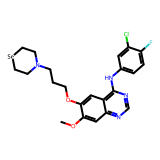
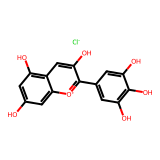
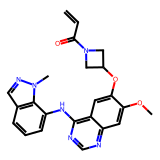
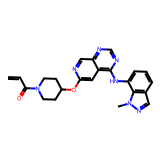

In [13]:
best_model = metrics_table.index[0]
by_error = results[results["model"] == best_model].sort_values("abs_error")
cols = ["molecule_chembl_id", "smiles", "y_true", "y_pred", "abs_error"]

print(f"Best model: {best_model}")
best_10 = by_error.head(10)[cols].reset_index(drop=True)
worst_10 = by_error.tail(10).sort_values("abs_error", ascending=False)[cols].reset_index(drop=True)


def mol_to_img_tag(smiles: str, size: int = 160) -> str:
    """Render a SMILES string as a base64 embedded PNG <img> tag.

    Embedding the image directly in the HTML (rather than saving files and
    linking to them) keeps the rendered table fully self-contained and
    portable, since the underlying structure comes only from a SMILES
    string in this results table, not a saved image file.
    """
    mol = Chem.MolFromSmiles(smiles)
    buf = BytesIO()
    Draw.MolToImage(mol, size=(size, size)).save(buf, format="PNG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    return f'<img src="data:image/png;base64,{b64}" width="{size}"/>'


def with_structure(df: pd.DataFrame) -> HTML:
    """Structure image column placed directly before smiles."""
    out = df.copy()
    out.insert(1, "structure", out["smiles"].apply(mol_to_img_tag))
    return HTML(out.to_html(escape=False, index=False))


print("\nBest 10 (lowest absolute error):")
display(with_structure(best_10))

print("\nWorst 10 (highest absolute error):")
display(with_structure(worst_10))

## 9. Why do models fail on specific molecules? Representation vs. activity cliffs

Two distinct, well known QSAR failure modes look the same in an error table
but have different remedies:

* **Sparse / underrepresented region** — few similar analogs in training data,
  so the model has little local signal to interpolate from. More diverse
  training data covering that region would plausibly help.
* **Activity cliff** — a near identical training analog exists (high Tanimoto
  similarity) but its measured potency differs sharply. ECFP based models
  predict similarity ≈ similar activity, so cliffs are hard *by construction*.
  Generic "more data" doesn't fix this unless the new data specifically
  resolves that SAR discontinuity (or the discontinuity is actually assay
  noise/mislabeling, in which case more data won't help either).

For every test molecule: find its nearest training set neighbor by Tanimoto
similarity, the neighbor's pIC50, and how many training molecules sit within
the AD threshold (a density/representation proxy). `sali` is the
Structure-Activity Landscape Index (`|Δ pIC50| / (1 − similarity)`), a
standard cheminformatics cliff detection score — large only when a close
neighbor has sharply different activity.

In [14]:
_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=config["features"]["ecfp_radius"], fpSize=N_BITS
)
train_fps = [_gen.GetFingerprint(Chem.MolFromSmiles(s)) for s in train_df["smiles"]]
train_pic50_arr = train_df["pIC50"].to_numpy()


def neighbor_diagnostics(smiles: str) -> dict:
    """Nearest training neighbor by Tanimoto similarity, plus the
    sparse-region vs. activity-cliff diagnostics from the markdown above.
    """
    fp = _gen.GetFingerprint(Chem.MolFromSmiles(smiles))
    sims = np.array(DataStructs.BulkTanimotoSimilarity(fp, train_fps))
    nn_idx = sims.argmax()
    return {
        "nn_similarity": sims[nn_idx],
        "nn_pIC50": train_pic50_arr[nn_idx],
        "n_neighbors_in_domain": int((sims >= AD_THRESHOLD).sum()),
    }


diag = pd.DataFrame(test_df["smiles"].apply(neighbor_diagnostics).tolist())
diag["molecule_chembl_id"] = test_df["molecule_chembl_id"].values
diag["delta_pIC50"] = (test_df["pIC50"].values - diag["nn_pIC50"]).abs()
# SALI = activity gap / (1 - similarity): large only when a near-identical
# neighbor has sharply different potency, i.e. an activity cliff.
diag["sali"] = diag["delta_pIC50"] / (1 - diag["nn_similarity"] + 1e-6)
diag.describe().round(2)

,nn_similarity,nn_pIC50,n_neighbors_in_domain,delta_pIC50,sali
count,1051.00,1051.00,1051.00,1051.00,1051.00
mean,0.69,6.98,106.48,0.78,7857.57
std,0.18,1.35,142.60,0.81,71267.34
min,0.14,2.52,0.00,0.00,0.00
25%,0.60,6.00,9.00,0.19,0.72
50%,0.74,7.05,41.00,0.54,2.12
75%,0.82,8.01,164.00,1.07,4.17
max,1.00,11.22,773.00,5.26,1075000.00


### Does error correlate more with sparsity or with cliff size?

Answers "would more data help" empirically for this dataset/model, rather
than guessing.

In [15]:
best_results = results[results["model"] == best_model].merge(
    diag.drop(columns="nn_similarity"), on="molecule_chembl_id", how="left"
)

print(f"Spearman correlation with {best_model} abs_error:\n")
for col, meaning in [
    ("n_neighbors_in_domain", "representation (higher = more analogs in train)"),
    ("nn_similarity", "closeness to nearest train neighbor"),
    ("delta_pIC50", "activity gap to nearest neighbor (cliff size)"),
    ("sali", "SALI cliff score"),
]:
    rho, p = spearmanr(best_results["abs_error"], best_results[col])
    print(f"  {col:22s} rho={rho:+.3f}  p={p:.2e}   ({meaning})")

Spearman correlation with random_forest abs_error:

  n_neighbors_in_domain  rho=-0.157  p=3.38e-07   (representation (higher = more analogs in train))
  nn_similarity          rho=-0.273  p=2.09e-19   (closeness to nearest train neighbor)
  delta_pIC50            rho=+0.466  p=6.97e-58   (activity gap to nearest neighbor (cliff size))
  sali                   rho=+0.315  p=1.11e-25   (SALI cliff score)


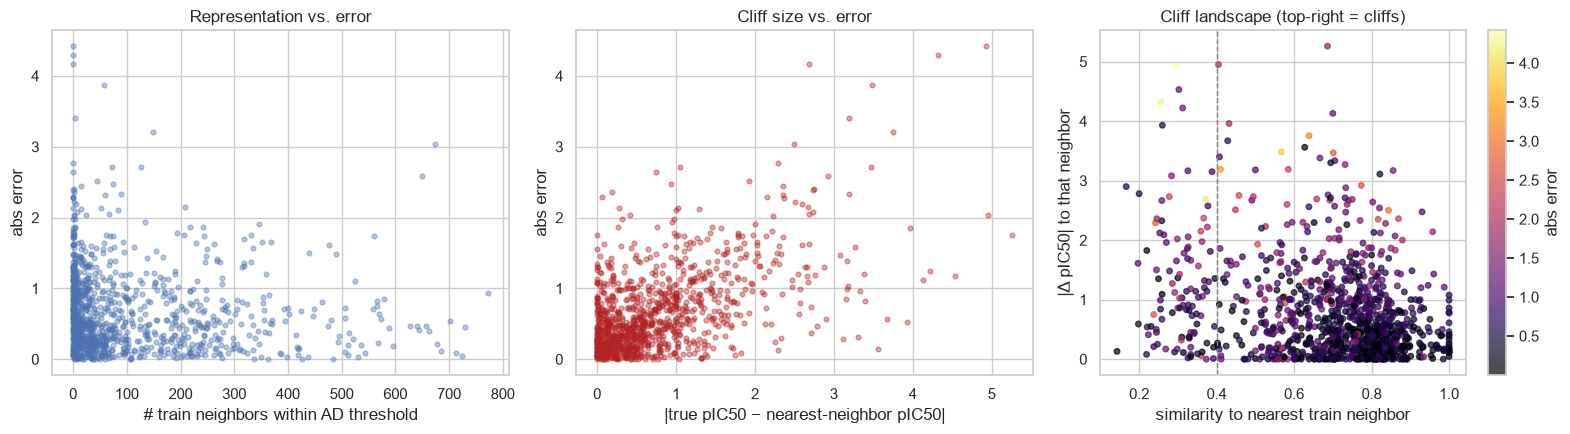

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(best_results["n_neighbors_in_domain"], best_results["abs_error"], alpha=0.4, s=12)
axes[0].set_xlabel("# train neighbors within AD threshold")
axes[0].set_ylabel("abs error")
axes[0].set_title("Representation vs. error")

axes[1].scatter(best_results["delta_pIC50"], best_results["abs_error"], alpha=0.4, s=12, color="firebrick")
axes[1].set_xlabel("|true pIC50 − nearest-neighbor pIC50|")
axes[1].set_ylabel("abs error")
axes[1].set_title("Cliff size vs. error")

sc = axes[2].scatter(
    best_results["nn_similarity"], best_results["delta_pIC50"],
    c=best_results["abs_error"], cmap="inferno", alpha=0.7, s=16,
)
axes[2].axvline(AD_THRESHOLD, ls="--", color="grey", lw=1)
axes[2].set_xlabel("similarity to nearest train neighbor")
axes[2].set_ylabel("|Δ pIC50| to that neighbor")
axes[2].set_title("Cliff landscape (top-right = cliffs)")
plt.colorbar(sc, ax=axes[2], label="abs error")

plt.tight_layout()
plt.show()

### Diagnosing the worst 10

Thresholds are the standard rule of thumb cutoffs (similarity ≥ 0.5,
|Δ pIC50| ≥ 1.5 log units, ≤2 in domain neighbors) — adjust if a stricter
definition is wanted.

molecule_chembl_id,structure,smiles,y_true,y_pred,abs_error,nn_similarity,delta_pIC50,n_neighbors_in_domain,diagnosis
CHEMBL6170958,,CCOc1ccc(/C=C2/C(=O)N(c3ccc(Cl)cc3)N=C2C)cc1,9.920,5.500501,4.419499,0.295082,4.930,0,sparse / underrepresented
CHEMBL6152892,,CCOc1ccc(C2C(C#N)=C(N)OC3C2C(C)=NN3c2ccc(Cl)cc2)cc1,9.680,5.389664,4.290336,0.255556,4.320,0,sparse / underrepresented
CHEMBL5192793,,COc1ccc(-c2cc(=O)cc(-c3ccc(OC)cc3)o2)cc1,9.820,5.652400,4.167600,0.372549,2.690,0,sparse / underrepresented
CHEMBL261238,,CN(c1cccnc1)c1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cn1,2.300,6.174850,3.874850,0.567164,3.480,57,activity cliff
CHEMBL6132839,,O=C(CSc1nnc(Nc2ccccc2)s1)N1N=C(c2ccccc2)CC1c1ccc([N+](=O)[O-])cc1,8.700,5.294900,3.405100,0.410256,3.190,3,other (model or assay noise)
CHEMBL5886380,,C=CC(=O)Nc1cccc(Nc2nc(Nc3cccc4c3CCN(C(C)=O)C4)ncc2C(F)(F)F)c1,3.945,7.157850,3.212850,0.638554,3.755,149,activity cliff
CHEMBL4858176,,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC[Se]CC1,4.600,7.644150,3.044150,0.843750,2.500,673,activity cliff
CHEMBL590878,,Oc1cc(O)c2cc(O)c(-c3cc(O)c(O)c(O)c3)[o+]c2c1.[Cl-],8.200,5.435950,2.764050,0.242424,2.290,0,sparse / underrepresented
CHEMBL5901984,,C=CC(=O)N1CC(Oc2cc3c(Nc4cccc5cnn(C)c45)ncnc3cc2OC)C1,4.845,7.561300,2.716300,0.701299,3.465,126,activity cliff
CHEMBL5863176,,C=CC(=O)N1CCC(Oc2cc3c(Nc4cccc5cnn(C)c45)ncnc3cn2)CC1,4.540,7.253050,2.713050,0.574713,1.050,72,other (model or assay noise)

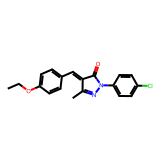
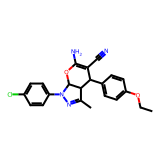
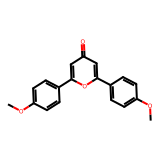
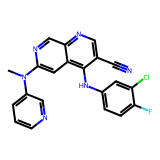
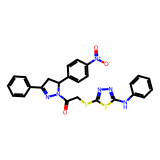
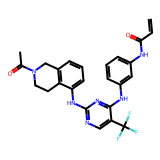
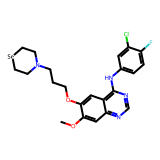
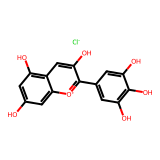
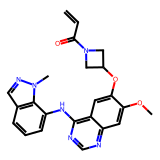
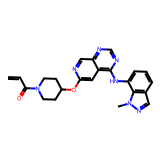

diagnosis
sparse / underrepresented       4
activity cliff                  4
other (model or assay noise)    2
Name: count, dtype: int64


In [17]:
def diagnose(row) -> str:
    """Bucket one test molecule's likely failure mode using the rule of
    thumb thresholds above; a molecule can be both a cliff and sparse at
    once, which is itself informative (worst of both problems).
    """
    is_cliff = row.nn_similarity >= 0.5 and row.delta_pIC50 >= 1.5
    is_sparse = row.n_neighbors_in_domain <= 2
    if is_cliff and is_sparse:
        return "cliff + sparse"
    if is_cliff:
        return "activity cliff"
    if is_sparse:
        return "sparse / underrepresented"
    return "other (model or assay noise)"

worst_diag = worst_10.merge(diag, on="molecule_chembl_id", how="left")
worst_diag["diagnosis"] = worst_diag.apply(diagnose, axis=1)

show_cols = ["molecule_chembl_id", "smiles", "y_true", "y_pred", "abs_error",
             "nn_similarity", "delta_pIC50", "n_neighbors_in_domain", "diagnosis"]
display(with_structure(worst_diag[show_cols]))
print(worst_diag["diagnosis"].value_counts())

### Failure mode across the worst 100 (not just worst 10)

10 molecules is too small a sample to call a majority cause. Extending the
same rule-of-thumb diagnosis to the worst 100 predictions (~10% of the test
set) gives a more statistically meaningful breakdown of why this model's
biggest errors happen.

diagnosis
activity cliff                  35
other (model or assay noise)    32
sparse / underrepresented       30
cliff + sparse                   3
Name: count, dtype: int64


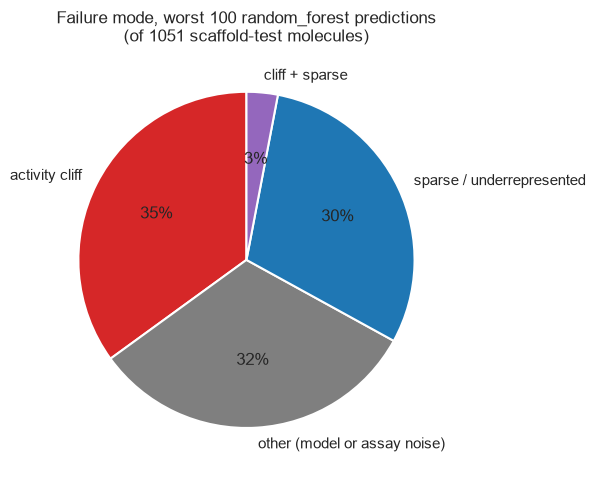

In [18]:
worst_100 = best_results.sort_values("abs_error", ascending=False).head(100).copy()
worst_100["diagnosis"] = worst_100.apply(diagnose, axis=1)

diag_counts = worst_100["diagnosis"].value_counts()
print(diag_counts)

colors = {
    "activity cliff": "#d62728",
    "sparse / underrepresented": "#1f77b4",
    "other (model or assay noise)": "#7f7f7f",
    "cliff + sparse": "#9467bd",
}
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    diag_counts.values,
    labels=diag_counts.index,
    autopct="%1.0f%%",
    colors=[colors[k] for k in diag_counts.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title(f"Failure mode, worst 100 {best_model} predictions\n(of {len(best_results)} scaffold-test molecules)")
plt.tight_layout()
plt.show()

## 10. Molecules where every model fails

Per molecule, `min_abs_error` is the error of *whichever model does best on
that specific molecule*. Ranking by this (rather than any one model's worst
list) surfaces molecules that are hard no matter which architecture or
descriptor is used — the strongest signal of a data problem (assay noise,
tautomer/salt handling, mislabeled activity) rather than a model specific
weakness.

molecule_chembl_id,structure,smiles,y_true,random_forest,chemeleon_finetune,lightgbm,xgboost,chemprop_default,chemprop_dmpnn_hpo,mpnn_scratch,min_abs_error,nn_similarity,delta_pIC50,diagnosis
CHEMBL261238,,CN(c1cccnc1)c1cc2c(Nc3ccc(F)c(Cl)c3)c(C#N)cnc2cn1,2.30,3.87,4.17,4.15,4.63,4.49,4.17,4.65,3.87,0.57,3.48,activity cliff
CHEMBL6152892,,CCOc1ccc(C2C(C#N)=C(N)OC3C2C(C)=NN3c2ccc(Cl)cc2)cc1,9.68,4.29,3.79,4.31,4.61,4.14,4.37,3.90,3.79,0.26,4.32,sparse / underrepresented
CHEMBL5192793,,COc1ccc(-c2cc(=O)cc(-c3ccc(OC)cc3)o2)cc1,9.82,4.17,3.74,4.16,4.70,4.74,4.17,4.29,3.74,0.37,2.69,sparse / underrepresented
CHEMBL6170958,,CCOc1ccc(/C=C2/C(=O)N(c3ccc(Cl)cc3)N=C2C)cc1,9.92,4.42,4.43,3.73,3.92,5.01,4.99,4.25,3.73,0.30,4.93,sparse / underrepresented
CHEMBL6132839,,O=C(CSc1nnc(Nc2ccccc2)s1)N1N=C(c2ccccc2)CC1c1ccc([N+](=O)[O-])cc1,8.70,3.41,2.91,3.00,3.64,4.12,3.35,2.97,2.91,0.41,3.19,other (model or assay noise)
CHEMBL4858176,,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CC[Se]CC1,4.60,3.04,2.96,3.06,3.24,3.48,2.79,2.89,2.79,0.84,2.50,activity cliff
CHEMBL5886380,,C=CC(=O)Nc1cccc(Nc2nc(Nc3cccc4c3CCN(C(C)=O)C4)ncc2C(F)(F)F)c1,3.94,3.21,2.95,2.87,3.27,3.14,3.36,2.65,2.65,0.64,3.76,activity cliff
CHEMBL5221067,,N#Cc1c(NC(=O)CNc2n[nH]c3ncccc23)sc2c1CCCC2,9.33,2.64,3.30,3.30,2.96,3.66,3.52,2.85,2.64,0.24,0.75,sparse / underrepresented
CHEMBL5881155,,CCOC(=O)C1=C(C(F)(F)F)NC2=C(C(=O)CC(C)(C)C2)C1c1ccc(S(=O)(=O)c2ccccc2)cc1,9.66,2.36,2.72,3.16,3.45,2.75,3.59,3.46,2.36,0.56,0.19,sparse / underrepresented
CHEMBL4280817,,O=C1CSC(N2N=C(c3ccncc3)CC2c2ccc(Br)cc2)=N1,8.05,2.32,2.39,2.64,2.64,3.03,2.48,2.40,2.32,0.87,2.36,activity cliff

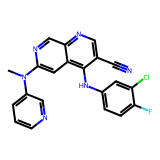
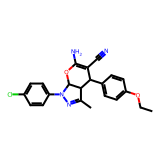
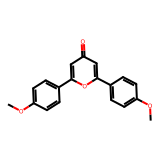
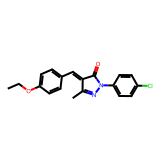
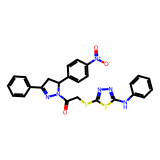
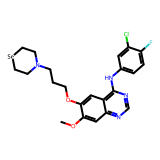
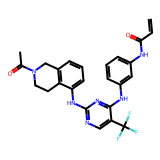
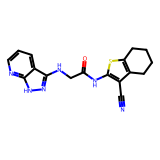
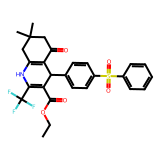
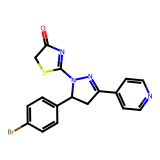
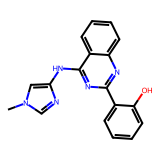
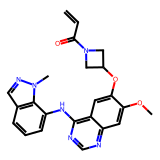
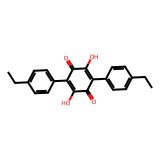
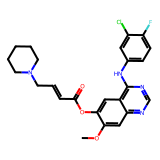
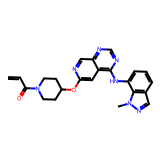

diagnosis
sparse / underrepresented       7
activity cliff                  6
other (model or assay noise)    2
Name: count, dtype: int64


In [19]:
pivot_err = results.pivot_table(index="molecule_chembl_id", columns="model", values="abs_error")
pivot_meta = results.drop_duplicates("molecule_chembl_id").set_index("molecule_chembl_id")[["smiles", "y_true"]]

pivot_err["min_abs_error"] = pivot_err[models_order].min(axis=1)
pivot_err["mean_abs_error"] = pivot_err[models_order].mean(axis=1)

universally_hard = (
    pivot_err.join(pivot_meta)
    .merge(diag.set_index("molecule_chembl_id")[["nn_similarity", "delta_pIC50", "n_neighbors_in_domain"]],
           left_index=True, right_index=True, how="left")
    .sort_values("min_abs_error", ascending=False)
    .head(15)
    .reset_index()
)
universally_hard["diagnosis"] = universally_hard.apply(diagnose, axis=1)

show_cols = (["molecule_chembl_id", "smiles", "y_true"] + models_order
             + ["min_abs_error", "nn_similarity", "delta_pIC50", "diagnosis"])
display(with_structure(universally_hard[show_cols].round(2)))
print(universally_hard["diagnosis"].value_counts())

## 11. Chemical space (UMAP) — test set error landscape

ECFP4 fingerprints (radius 2, 2048 bits — same descriptor used to train the
classical models) for the **entire curated dataset** (train+val+test),
projected to 2D with UMAP (Jaccard metric, same settings as
`02_eda_chemical_space.ipynb` for comparability).

Rather than only marking 30 points on an otherwise blank cloud, every test
molecule is colored by its absolute error — that turns the plot into an
actual error landscape (where in chemical space does the best model
struggle?) instead of two dots that happen to be red or green. Train/val
molecules sit underneath as light grey context. The worst/best 10 are
outlined on top for the specific callouts from section 8.

Hover any point for its ChEMBL ID, SMILES, and — for test set molecules —
true pIC50, predicted pIC50, absolute error, and the representation/cliff
diagnostics from section 9.

In [20]:
# Only cell that needs data outside the three scaffold splits.
full_df = pd.read_csv(ROOT / config["data"]["curated_csv"])
valid = full_df["smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None)
full_df = full_df[valid].reset_index(drop=True)
print(f"{len(full_df)} / {len(valid)} molecules parse with RDKit")

X_full = featurize(full_df, kind="ecfp", n_bits=N_BITS)

print("Running UMAP (Jaccard, n_neighbors=30) — takes ~1-2 min for ~10k molecules...")
# Jaccard = 1 - Tanimoto for binary fingerprints; same settings as the EDA notebook.
reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="jaccard", random_state=SEED)
embedding = reducer.fit_transform(X_full)
full_df["umap_x"], full_df["umap_y"] = embedding[:, 0], embedding[:, 1]
print("Done.")

10502 / 10502 molecules parse with RDKit


Running UMAP (Jaccard, n_neighbors=30) — takes ~1-2 min for ~10k molecules...


/opt/miniconda3/envs/egfr-env/lib/python3.11/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
/opt/miniconda3/envs/egfr-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Done.


In [21]:
pred_cols = results[results["model"] == best_model][["molecule_chembl_id", "y_pred", "abs_error"]]
full_df = full_df.merge(pred_cols, on="molecule_chembl_id", how="left")
full_df = full_df.merge(
    diag[["molecule_chembl_id", "nn_similarity", "delta_pIC50", "n_neighbors_in_domain"]],
    on="molecule_chembl_id", how="left",
)

full_df["status"] = np.where(full_df["abs_error"].notna(), "test", "background")
full_df.loc[full_df["molecule_chembl_id"].isin(best_10["molecule_chembl_id"]), "status"] = "best10"
full_df.loc[full_df["molecule_chembl_id"].isin(worst_10["molecule_chembl_id"]), "status"] = "worst10"


def hover_text(row) -> str:
    """Plotly hover tooltip; test molecules get prediction/error/AD
    diagnostics, background molecules only get identity info.
    """
    text = f"ChEMBL: {row.molecule_chembl_id}<br>SMILES: {row.smiles}<br>true pIC50: {row.pIC50:.2f}"
    if pd.notna(row.y_pred):
        text += (
            f"<br>pred pIC50 ({best_model}): {row.y_pred:.2f}<br>abs error: {row.abs_error:.2f}"
            f"<br>nn similarity: {row.nn_similarity:.2f}  |  Δ nn pIC50: {row.delta_pIC50:.2f}"
            f"<br># train neighbors in-domain: {int(row.n_neighbors_in_domain)}"
        )
    return text


full_df["hover"] = full_df.apply(hover_text, axis=1)
full_df["status"].value_counts()

status
background    9451
test          1031
best10          10
worst10         10
Name: count, dtype: int64

In [22]:
fig = go.Figure()

bg = full_df[full_df["status"] == "background"]
fig.add_trace(go.Scattergl(
    x=bg["umap_x"], y=bg["umap_y"], mode="markers",
    marker=dict(color="#dcdcdc", size=3, opacity=0.45),
    text=bg["hover"], hoverinfo="text", name="train/val (context)",
))

test_pts = full_df[full_df["status"] == "test"]
error_cap = full_df["abs_error"].quantile(0.98)  # clip so outliers don't wash out the scale
fig.add_trace(go.Scattergl(
    x=test_pts["umap_x"], y=test_pts["umap_y"], mode="markers",
    marker=dict(
        color=test_pts["abs_error"], colorscale="Inferno", cmin=0, cmax=error_cap,
        size=7, opacity=0.85, line=dict(width=0.5, color="white"),
        colorbar=dict(title="abs error", x=1.02, len=0.75),
    ),
    text=test_pts["hover"], hoverinfo="text", name="test set (color = abs error)",
))

for status, color, symbol in [("best10", "#2ca02c", "circle"), ("worst10", "#d62728", "x")]:
    pts = full_df[full_df["status"] == status]
    fig.add_trace(go.Scattergl(
        x=pts["umap_x"], y=pts["umap_y"], mode="markers",
        marker=dict(color=color, size=15, symbol=symbol, line=dict(width=2, color="black")),
        text=pts["hover"], hoverinfo="text", name=status,
    ))

fig.update_layout(
    template="plotly_white",
    width=980, height=700,
    title=dict(
        text=(f"Chemical space (ECFP4 UMAP) — test-set error landscape, {best_model}"
              "<br><sup>grey = train/val context · colored = test predictions by |error| "
              "· outlined markers = best/worst 10</sup>"),
    ),
    xaxis_title="UMAP 1", yaxis_title="UMAP 2",
    legend=dict(orientation="h", yanchor="bottom", y=1.06, x=0),
    margin=dict(t=100),
)
fig.show()

## 12. Summary

Persists the headline metrics table, plus the in domain/out of domain error
breakdown from section 7, as `results/model_comparison_scaffold_test.csv` —
a single reusable artifact for the portfolio writeup rather than numbers
scattered across notebook cells.

In [23]:
summary = metrics_table.copy()
summary["mean_abs_error_out_of_domain"] = (
    results[~results["in_domain"]].groupby("model")["abs_error"].mean()
)
summary["mean_abs_error_in_domain"] = (
    results[results["in_domain"]].groupby("model")["abs_error"].mean()
)
summary.to_csv(ROOT / config["results_dir"] / "model_comparison_scaffold_test.csv")
summary

,rmse,mae,r2,spearman,mean_abs_error_out_of_domain,mean_abs_error_in_domain
model,,,,,,
random_forest,0.889454,0.665822,0.516317,0.732900,1.027721,0.625654
chemeleon_finetune,0.933912,0.722148,0.466757,0.681743,1.048785,0.685893
lightgbm,0.934020,0.710831,0.466634,0.699646,1.046245,0.673602
xgboost,0.947434,0.714775,0.451204,0.690528,1.083005,0.673904
chemprop_default,0.972359,0.731977,0.421948,0.676000,1.149661,0.685616
chemprop_dmpnn_hpo,0.989050,0.744030,0.401933,0.643408,1.063938,0.708522
mpnn_scratch,1.154235,0.925811,0.185480,0.424927,1.109290,0.905446


**Findings to carry forward:**

* Headline ranking is by scaffold split test RMSE/MAE/R²/Spearman (section 4) — random split numbers are never reported as the primary result per project convention.
* Applicability domain (section 7): check whether the "gap" column (out of domain minus in domain mean abs error) is positive and similar in size across models — if one model's gap is much larger, its extrapolation behavior is less trustworthy even if its overall RMSE looks fine.
* Why models fail (section 9): compare the two Spearman rhos printed there — if `n_neighbors_in_domain` correlates with error more strongly than `delta_pIC50`/`sali`, the failures are mainly a **data coverage** problem (more diverse training data would plausibly help); if the cliff metrics dominate, they're **activity cliffs** that more data won't fix unless it specifically resolves that SAR discontinuity.
* Molecules where every model fails (section 10): these are the strongest candidates for a genuine **data/assay problem** (mislabeled activity, wrong tautomer/salt form, misparsed SMILES) rather than a modeling weakness — worth a manual lookup in ChEMBL before trusting any model's prediction on similar compounds.
* The UMAP (section 11): check whether the worst 10 cluster in a sparse/edge region of chemical space (data coverage problem, section 9) versus sitting inside the dense cloud with a high similarity/high Δ hover reading (activity cliff, section 9).